# VehiclePositions -> TripUpdates Transformation Sandbox

This notebook builds a daily transformation that:

1. Parses `VehiclePositions` blobs into a flattened dataframe.
2. Condenses VehiclePositions to latest record per composite key.
3. Left joins condensed VehiclePositions onto TripUpdates latest.
4. Reports join coverage and exports output parquet.

## Target behavior
- VehiclePositions key: trip-level + stop-sequence context
- Keep most recent vehicle observation per key
- Left join onto TripUpdates latest so every TripUpdates row is retained (1-to-1 or 1-to-0)

In [11]:
from google.cloud import storage
from google.transit import gtfs_realtime_pb2
import pandas as pd
from tqdm.auto import tqdm
from pathlib import Path

# ------------------------------
# Step 1: Run configuration
# ------------------------------
agency_id = "muni"
service_date = "2026-06-23"
bucket_name = "511_transit_data"
vp_prefix = f"VehiclePositions/{agency_id}/{service_date}/"

# Path to TripUpdates latest output (edit if needed).
tripupdates_latest_path = Path(
    f"trip_stop_prediction_latest_{agency_id}_{service_date}.parquet"
)
if not tripupdates_latest_path.exists():
    # Fallback to sample file name if full-day output not present.
    tripupdates_latest_path = Path("trip_stop_prediction_latest_muni_2026-06-23.parquet")

# Optional sampling for VehiclePositions parse iteration.
sample_mode = False
sample_n_blobs = 200
sample_every_k = None  # e.g. 10 -> every 10th blob

output_joined_parquet = Path(
    f"tripupdates_with_vehicle_latest_{agency_id}_{service_date}.parquet"
)
if sample_mode:
    output_joined_parquet = Path(
        f"tripupdates_with_vehicle_latest_{agency_id}_{service_date}_sample{sample_n_blobs}.parquet"
    )

print(f"VehiclePositions prefix: {vp_prefix}")
print(f"TripUpdates latest path: {tripupdates_latest_path}")
print(f"TripUpdates path exists: {tripupdates_latest_path.exists()}")
print(f"Sample mode: {sample_mode}")
print(f"sample_n_blobs: {sample_n_blobs}")
print(f"sample_every_k: {sample_every_k}")
print(f"Output parquet: {output_joined_parquet}")

VehiclePositions prefix: VehiclePositions/muni/2026-06-23/
TripUpdates latest path: trip_stop_prediction_latest_muni_2026-06-23.parquet
TripUpdates path exists: True
Sample mode: False
sample_n_blobs: 200
sample_every_k: None
Output parquet: tripupdates_with_vehicle_latest_muni_2026-06-23.parquet


## Step 2 - Discover VehiclePositions blobs

In [12]:
def parse_snapshot_ts_from_blob_name(blob_name: str) -> pd.Timestamp:
    ts_text = blob_name.rsplit("/", 1)[-1].replace(".pb", "")
    return pd.to_datetime(
        ts_text, format="%Y-%m-%dT%H-%M-%S.%fZ", utc=True, errors="coerce"
    )


client = storage.Client()
vp_blobs = list(client.list_blobs(bucket_name, prefix=vp_prefix))

print(f"Found {len(vp_blobs):,} VehiclePositions blobs")
if not vp_blobs:
    raise ValueError("No VehiclePositions blobs found for date/prefix.")

vp_manifest = pd.DataFrame(
    {
        "blob_order": range(len(vp_blobs)),
        "blob_name": [b.name for b in vp_blobs],
    }
)
vp_manifest["filename_snapshot_ts"] = vp_manifest["blob_name"].map(parse_snapshot_ts_from_blob_name)

vp_parse_manifest = vp_manifest.copy()
if sample_mode:
    if sample_every_k is not None and sample_every_k > 1:
        vp_parse_manifest = vp_parse_manifest.iloc[::sample_every_k].copy()
    vp_parse_manifest = vp_parse_manifest.head(sample_n_blobs).copy()

vp_parse_blob_orders = vp_parse_manifest["blob_order"].tolist()
vp_parse_blobs = [vp_blobs[i] for i in vp_parse_blob_orders]

print(f"Blobs selected for parse: {len(vp_parse_blobs):,}")
print("Missing filename timestamp parses:", vp_parse_manifest["filename_snapshot_ts"].isna().sum())
display(vp_parse_manifest.head())

Found 1,438 VehiclePositions blobs
Blobs selected for parse: 1,438
Missing filename timestamp parses: 0


,blob_order,blob_name,filename_snapshot_ts
0,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52.051568+00:00
1,1,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:01:59.772002+00:00
2,2,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:04:03.594376+00:00
3,3,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:04:10.994943+00:00
4,4,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:05:10.713848+00:00


## Step 3 - Parse and flatten VehiclePositions

One row per vehicle observation with trip/route/sequence context.

Primary timestamp:
- `vp_snapshot_ts` from feed header
- fallback: filename timestamp

In [13]:
vp_rows = []

for blob_order, blob in tqdm(
    zip(vp_parse_blob_orders, vp_parse_blobs),
    total=len(vp_parse_blobs),
    desc="Parsing VehiclePositions",
):
    feed = gtfs_realtime_pb2.FeedMessage()
    feed.ParseFromString(blob.download_as_bytes())

    filename_snapshot_ts = parse_snapshot_ts_from_blob_name(blob.name)
    header_snapshot_ts = pd.NaT
    if feed.HasField("header") and feed.header.HasField("timestamp"):
        header_snapshot_ts = pd.to_datetime(
            feed.header.timestamp, unit="s", utc=True, errors="coerce"
        )

    if pd.notna(header_snapshot_ts):
        vp_snapshot_ts = header_snapshot_ts
        vp_snapshot_ts_source = "header"
    else:
        vp_snapshot_ts = filename_snapshot_ts
        vp_snapshot_ts_source = "filename_fallback"

    for entity in feed.entity:
        if not entity.HasField("vehicle"):
            continue

        vp = entity.vehicle
        trip = vp.trip
        vehicle = vp.vehicle
        position = vp.position

        trip_id = trip.trip_id if trip.trip_id else None
        route_id = trip.route_id if trip.route_id else None
        direction_id = trip.direction_id if trip.HasField("direction_id") else None
        current_stop_sequence = (
            int(vp.current_stop_sequence)
            if vp.HasField("current_stop_sequence")
            else None
        )
        stop_id = vp.stop_id if vp.stop_id else None
        current_status = int(vp.current_status) if vp.HasField("current_status") else None

        vehicle_id = vehicle.id if vehicle.id else None
        vehicle_label = vehicle.label if vehicle.label else None

        position_timestamp = pd.NaT
        if vp.HasField("timestamp"):
            position_timestamp = pd.to_datetime(vp.timestamp, unit="s", utc=True, errors="coerce")

        latitude = (
            position.latitude if vp.HasField("position") and position.HasField("latitude") else None
        )
        longitude = (
            position.longitude if vp.HasField("position") and position.HasField("longitude") else None
        )
        bearing = (
            position.bearing if vp.HasField("position") and position.HasField("bearing") else None
        )
        speed = position.speed if vp.HasField("position") and position.HasField("speed") else None

        vp_rows.append(
            {
                "agency_id": agency_id,
                "blob_order": blob_order,
                "blob_name": blob.name,
                "vp_snapshot_ts": vp_snapshot_ts,
                "vp_snapshot_ts_source": vp_snapshot_ts_source,
                "position_timestamp": position_timestamp,
                "trip_id": trip_id,
                "route_id": route_id,
                "direction_id": direction_id,
                "stop_sequence": current_stop_sequence,
                "vp_stop_id": stop_id,
                "current_status": current_status,
                "vehicle_id": vehicle_id,
                "vehicle_label": vehicle_label,
                "latitude": latitude,
                "longitude": longitude,
                "bearing": bearing,
                "speed": speed,
            }
        )

df_vp_raw = pd.DataFrame(vp_rows)
print(f"Flattened VehiclePositions rows: {len(df_vp_raw):,}")
print("Null-rate for join key fields:")
display(df_vp_raw[["trip_id", "direction_id", "stop_sequence", "vp_snapshot_ts"]].isna().mean())
display(df_vp_raw.head())

Parsing VehiclePositions:   0%|          | 0/1438 [00:00<?, ?it/s]

Flattened VehiclePositions rows: 829,137
Null-rate for join key fields:


trip_id           0.368136
direction_id      0.368136
stop_sequence     0.372036
vp_snapshot_ts    0.000000
dtype: float64

,agency_id,blob_order,blob_name,vp_snapshot_ts,vp_snapshot_ts_source,position_timestamp,trip_id,route_id,direction_id,stop_sequence,vp_stop_id,current_status,vehicle_id,vehicle_label,latitude,longitude,bearing,speed
0,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,None,None,NaN,NaN,None,NaN,1,1,37.794949,-122.412209,0.0,0.00
1,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,None,None,NaN,NaN,None,NaN,10,10,37.794739,-122.410042,0.0,0.00
2,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,12081054_M41,F,1.0,30.0,15184,0.0,1010,1010,37.807434,-122.417427,0.0,0.00
3,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,12080952_M41,F,0.0,27.0,15690,1.0,1015,1015,37.766357,-122.430496,210.0,6.39
4,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,12081057_M41,F,1.0,13.0,15645,2.0,1050,1050,37.781578,-122.411156,30.0,7.50


## Step 4 - Condense VehiclePositions to latest record per key

Vehicle latest key:
- `agency_id`, `trip_id`, `direction_id`, `stop_sequence`

This mirrors the stop-level grain used for TripUpdates matching.

In [14]:
vp_key = ["agency_id", "trip_id", "direction_id", "stop_sequence"]

vp_for_latest = df_vp_raw.dropna(subset=["trip_id", "stop_sequence", "vp_snapshot_ts"]).copy()

# Keep most recent vehicle observation per key.
df_vp_latest = (
    vp_for_latest.sort_values(["vp_snapshot_ts", "blob_order", "blob_name"], ascending=[True, True, True])
    .drop_duplicates(subset=vp_key, keep="last")
    .reset_index(drop=True)
)

print(f"Vehicle raw rows (usable): {len(vp_for_latest):,}")
print(f"Vehicle latest rows: {len(df_vp_latest):,}")
print(f"Rows removed by dedupe: {len(vp_for_latest) - len(df_vp_latest):,}")

display(df_vp_latest.head())

Vehicle raw rows (usable): 520,659
Vehicle latest rows: 203,088
Rows removed by dedupe: 317,571


,agency_id,blob_order,blob_name,vp_snapshot_ts,vp_snapshot_ts_source,position_timestamp,trip_id,route_id,direction_id,stop_sequence,vp_stop_id,current_status,vehicle_id,vehicle_label,latitude,longitude,bearing,speed
0,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,12081055_M41,F,1.0,25.0,17281,2.0,1057,1057,37.795277,-122.394112,315.0,5.28
1,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,12080956_M41,F,0.0,1.0,15184,1.0,1058,1058,37.807243,-122.417389,165.0,0.00
2,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,12081058_M41,F,1.0,6.0,15675,1.0,1071,1071,37.770561,-122.425072,0.0,0.00
3,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,12085066_M41,N,0.0,27.0,15209,2.0,2014,2014,37.761189,-122.488754,255.0,3.89
4,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,12087195_M41,T,0.0,8.0,17402,2.0,2032,2032,37.731579,-122.391838,15.0,0.00


## Step 5 - Load TripUpdates latest table

This should be your condensed TripUpdates output parquet.

In [15]:
if not tripupdates_latest_path.exists():
    raise ValueError(
        f"TripUpdates latest parquet not found: {tripupdates_latest_path}. "
        "Update tripupdates_latest_path in config cell."
    )

df_tu_latest = pd.read_parquet(tripupdates_latest_path)
print(f"TripUpdates latest rows: {len(df_tu_latest):,}")
print("TripUpdates columns:", sorted(df_tu_latest.columns.tolist()))
display(df_tu_latest.head())

TripUpdates latest rows: 376,283
TripUpdates columns: ['agency_id', 'arrival_delay_sec', 'arrival_time_predicted', 'departure_delay_sec', 'departure_time_predicted', 'direction_id', 'latest_snapshot_ts', 'route_id', 'stop_id', 'stop_sequence', 'trip_id', 'trip_start_date', 'trip_start_time']


,agency_id,trip_id,trip_start_date,trip_start_time,route_id,direction_id,stop_sequence,stop_id,latest_snapshot_ts,arrival_time_predicted,departure_time_predicted,arrival_delay_sec,departure_delay_sec
0,muni,12052973_M41,2026-06-22,None,1,0,1,14015,2026-06-23 02:35:23+00:00,NaT,2026-06-23 02:36:27+00:00,NaN,87.0
1,muni,12052973_M41,2026-06-22,None,1,0,2,16294,2026-06-23 02:36:02+00:00,2026-06-23 02:36:06+00:00,NaT,17.0,NaN
2,muni,12052973_M41,2026-06-22,None,1,0,3,16290,2026-06-23 02:37:37+00:00,2026-06-23 02:37:27+00:00,NaT,49.0,NaN
3,muni,12052973_M41,2026-06-22,None,1,0,4,16314,2026-06-23 02:37:37+00:00,2026-06-23 02:38:04+00:00,NaT,64.0,NaN
4,muni,12052973_M41,2026-06-22,None,1,0,5,16307,2026-06-23 02:39:11+00:00,2026-06-23 02:39:29+00:00,NaT,85.0,NaN


## Step 6 - Left join Vehicle latest onto TripUpdates latest

Join keys:
- `agency_id`
- `trip_id`
- `direction_id`
- `stop_sequence`

Result:
- one row per TripUpdates row
- optional vehicle fields when a match exists

In [16]:
# Ensure expected TU key columns exist.
required_tu_cols = {"agency_id", "trip_id", "direction_id", "stop_sequence"}
missing = required_tu_cols - set(df_tu_latest.columns)
if missing:
    raise ValueError(f"TripUpdates dataframe missing required columns: {missing}")

vehicle_cols_to_add = [
    "vp_snapshot_ts",
    "position_timestamp",
    "vp_stop_id",
    "current_status",
    "vehicle_id",
    "vehicle_label",
    "latitude",
    "longitude",
    "bearing",
    "speed",
]

df_joined = df_tu_latest.merge(
    df_vp_latest[["agency_id", "trip_id", "direction_id", "stop_sequence"] + vehicle_cols_to_add],
    on=["agency_id", "trip_id", "direction_id", "stop_sequence"],
    how="left",
)

# Coverage diagnostics.
match_rate = df_joined["vehicle_id"].notna().mean()
print(f"Joined rows: {len(df_joined):,}")
print(f"Vehicle match rate (vehicle_id not null): {match_rate:.2%}")

# Optional timing diagnostic for matched rows.
if "latest_snapshot_ts" in df_joined.columns:
    df_joined["tu_vp_snapshot_delta_sec"] = (
        df_joined["latest_snapshot_ts"] - df_joined["vp_snapshot_ts"]
    ).dt.total_seconds()

    print("Snapshot delta summary (TripUpdates - VehiclePositions) for matched rows:")
    display(
        df_joined.loc[df_joined["vehicle_id"].notna(), "tu_vp_snapshot_delta_sec"]
        .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    )

display(df_joined.head())

Joined rows: 376,283
Vehicle match rate (vehicle_id not null): 53.71%
Snapshot delta summary (TripUpdates - VehiclePositions) for matched rows:


count    202116.000000
mean        -93.901126
std         475.291011
min      -17725.000000
5%         -196.000000
25%         -93.000000
50%         -15.000000
75%          -2.000000
95%           9.000000
max        7067.000000
Name: tu_vp_snapshot_delta_sec, dtype: float64

,agency_id,trip_id,trip_start_date,trip_start_time,route_id,direction_id,stop_sequence,stop_id,latest_snapshot_ts,arrival_time_predicted,...,position_timestamp,vp_stop_id,current_status,vehicle_id,vehicle_label,latitude,longitude,bearing,speed,tu_vp_snapshot_delta_sec
0,muni,12052973_M41,2026-06-22,None,1,0,1,14015,2026-06-23 02:35:23+00:00,NaT,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,muni,12052973_M41,2026-06-22,None,1,0,2,16294,2026-06-23 02:36:02+00:00,2026-06-23 02:36:06+00:00,...,2026-06-23 02:36:03+00:00,16294,0.0,5768,5768,37.795418,-122.396965,150.0,2.78,-3.0
2,muni,12052973_M41,2026-06-22,None,1,0,3,16290,2026-06-23 02:37:37+00:00,2026-06-23 02:37:27+00:00,...,2026-06-23 02:37:35+00:00,16290,0.0,5768,5768,37.794395,-122.398827,255.0,0.00,-1.0
3,muni,12052973_M41,2026-06-22,None,1,0,4,16314,2026-06-23 02:37:37+00:00,2026-06-23 02:38:04+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,muni,12052973_M41,2026-06-22,None,1,0,5,16307,2026-06-23 02:39:11+00:00,2026-06-23 02:39:29+00:00,...,2026-06-23 02:39:07+00:00,16307,0.0,5768,5768,37.794018,-122.401085,255.0,6.67,-2.0


## Step 7 - Full outer join diagnostics (inspect both missing sides)

This is for QA/EDA.

`_merge` meanings:
- `both`: key appears in both TripUpdates latest and VehiclePositions latest
- `left_only`: appears only in TripUpdates latest
- `right_only`: appears only in VehiclePositions latest

In [17]:
df_full_join = df_tu_latest.merge(
    df_vp_latest[["agency_id", "trip_id", "direction_id", "stop_sequence"] + vehicle_cols_to_add],
    on=["agency_id", "trip_id", "direction_id", "stop_sequence"],
    how="outer",
    indicator=True,
)

print(f"Full join rows: {len(df_full_join):,}")
print("Merge category counts:")
display(df_full_join["_merge"].value_counts(dropna=False))

print("Merge category rates:")
display(df_full_join["_merge"].value_counts(normalize=True, dropna=False))

print("Sample rows present in both:")
display(df_full_join[df_full_join["_merge"] == "both"].head(10))

print("Sample rows only in TripUpdates (left_only):")
display(df_full_join[df_full_join["_merge"] == "left_only"].head(10))

print("Sample rows only in VehiclePositions (right_only):")
display(df_full_join[df_full_join["_merge"] == "right_only"].head(10))

# Optional convenience subsets for deeper debugging.
df_only_tu = df_full_join[df_full_join["_merge"] == "left_only"].copy()
df_only_vp = df_full_join[df_full_join["_merge"] == "right_only"].copy()

Full join rows: 377,495
Merge category counts:


_merge
both          202116
left_only     174167
right_only      1212
Name: count, dtype: int64

Merge category rates:


_merge
both          0.535414
left_only     0.461376
right_only    0.003211
Name: proportion, dtype: float64

Sample rows present in both:


,agency_id,trip_id,trip_start_date,trip_start_time,route_id,direction_id,stop_sequence,stop_id,latest_snapshot_ts,arrival_time_predicted,...,position_timestamp,vp_stop_id,current_status,vehicle_id,vehicle_label,latitude,longitude,bearing,speed,_merge
0,muni,12052958_M11,2026-06-23,None,1,0.0,1.0,13892,2026-06-23 11:30:51+00:00,NaT,...,2026-06-23 11:31:51+00:00,13892,2.0,5790,5790,37.786789,-122.446709,345.0,6.39,both
1,muni,12052958_M11,2026-06-23,None,1,0.0,2.0,13875,2026-06-23 11:32:06+00:00,2026-06-23 11:32:48+00:00,...,2026-06-23 11:32:06+00:00,13875,2.0,5790,5790,37.786789,-122.446709,345.0,6.39,both
3,muni,12052958_M11,2026-06-23,None,1,0.0,4.0,13852,2026-06-23 11:34:09+00:00,2026-06-23 11:34:10+00:00,...,2026-06-23 11:34:07+00:00,13852,0.0,5790,5790,37.786385,-122.454086,255.0,9.72,both
6,muni,12052958_M11,2026-06-23,None,1,0.0,7.0,13824,2026-06-23 11:35:23+00:00,2026-06-23 11:35:42+00:00,...,2026-06-23 11:35:23+00:00,13824,0.0,5790,5790,37.785118,-122.463837,255.0,8.89,both
7,muni,12052958_M11,2026-06-23,None,1,0.0,8.0,17160,2026-06-23 11:35:23+00:00,2026-06-23 11:36:18+00:00,...,2026-06-23 11:36:24+00:00,17160,1.0,5790,5790,37.784767,-122.466530,255.0,3.61,both
10,muni,12052958_M11,2026-06-23,None,1,0.0,11.0,13886,2026-06-23 11:37:45+00:00,2026-06-23 11:38:14+00:00,...,2026-06-23 11:37:40+00:00,13886,2.0,5790,5790,37.784588,-122.469635,270.0,5.83,both
11,muni,12052958_M11,2026-06-23,None,1,0.0,12.0,13833,2026-06-23 11:38:53+00:00,2026-06-23 11:39:12+00:00,...,2026-06-23 11:39:57+00:00,13833,1.0,5790,5790,37.784363,-122.474983,255.0,0.56,both
13,muni,12052958_M11,2026-06-23,None,1,0.0,14.0,13837,2026-06-23 11:41:18+00:00,2026-06-23 11:41:29+00:00,...,2026-06-23 11:41:28+00:00,13837,1.0,5790,5790,37.784061,-122.481628,255.0,4.44,both
16,muni,12052958_M11,2026-06-23,None,1,0.0,17.0,13843,2026-06-23 11:42:28+00:00,2026-06-23 11:43:10+00:00,...,2026-06-23 11:42:28+00:00,13843,0.0,5790,5790,37.783810,-122.486992,255.0,10.28,both
17,muni,12052958_M11,2026-06-23,None,1,0.0,18.0,13547,2026-06-23 11:42:28+00:00,2026-06-23 11:43:39+00:00,...,2026-06-23 11:43:59+00:00,13547,1.0,5790,5790,37.783577,-122.492317,255.0,7.22,both


Sample rows only in TripUpdates (left_only):


,agency_id,trip_id,trip_start_date,trip_start_time,route_id,direction_id,stop_sequence,stop_id,latest_snapshot_ts,arrival_time_predicted,...,position_timestamp,vp_stop_id,current_status,vehicle_id,vehicle_label,latitude,longitude,bearing,speed,_merge
2,muni,12052958_M11,2026-06-23,None,1,0.0,3.0,13896,2026-06-23 11:32:06+00:00,2026-06-23 11:33:38+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
4,muni,12052958_M11,2026-06-23,None,1,0.0,5.0,13845,2026-06-23 11:34:09+00:00,2026-06-23 11:34:41+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
5,muni,12052958_M11,2026-06-23,None,1,0.0,6.0,13822,2026-06-23 11:35:23+00:00,2026-06-23 11:35:09+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
8,muni,12052958_M11,2026-06-23,None,1,0.0,9.0,13828,2026-06-23 11:36:36+00:00,2026-06-23 11:36:52+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
9,muni,12052958_M11,2026-06-23,None,1,0.0,10.0,13831,2026-06-23 11:37:45+00:00,2026-06-23 11:37:30+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
12,muni,12052958_M11,2026-06-23,None,1,0.0,13.0,13835,2026-06-23 11:40:10+00:00,2026-06-23 11:40:08+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
14,muni,12052958_M11,2026-06-23,None,1,0.0,15.0,13839,2026-06-23 11:41:36+00:00,2026-06-23 11:41:53+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
15,muni,12052958_M11,2026-06-23,None,1,0.0,16.0,13841,2026-06-23 11:42:28+00:00,2026-06-23 11:42:38+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
18,muni,12052958_M11,2026-06-23,None,1,0.0,19.0,13549,2026-06-23 11:42:28+00:00,2026-06-23 11:44:07+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
20,muni,12052958_M11,2026-06-23,None,1,0.0,21.0,14277,2026-06-23 11:44:24+00:00,2026-06-23 11:44:58+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


Sample rows only in VehiclePositions (right_only):


,agency_id,trip_id,trip_start_date,trip_start_time,route_id,direction_id,stop_sequence,stop_id,latest_snapshot_ts,arrival_time_predicted,...,position_timestamp,vp_stop_id,current_status,vehicle_id,vehicle_label,latitude,longitude,bearing,speed,_merge
2085,muni,12053009_M11,NaN,NaN,NaN,0.0,1.0,NaN,NaT,NaT,...,2026-06-23 16:36:48+00:00,14277,2.0,5852,5852,37.779846,-122.492630,270.0,0.00,right_only
4448,muni,12053058_M41,NaN,NaN,NaN,0.0,8.0,NaN,NaT,NaT,...,2026-06-23 00:01:52+00:00,16316,1.0,5792,5792,37.793144,-122.407539,255.0,1.39,right_only
7241,muni,12053129_M41,NaN,NaN,NaN,0.0,1.0,NaN,NaT,NaT,...,2026-06-23 00:19:23+00:00,16313,2.0,5846,5846,37.788094,-122.447449,75.0,2.22,right_only
7242,muni,12053129_M41,NaN,NaN,NaN,0.0,11.0,NaN,NaT,NaT,...,2026-06-23 00:00:51+00:00,16301,1.0,5846,5846,37.792366,-122.414223,255.0,0.83,right_only
7290,muni,12053130_M41,NaN,NaN,NaN,0.0,1.0,NaN,NaT,NaT,...,2026-06-23 00:29:39+00:00,16313,2.0,5874,5874,37.788105,-122.447456,90.0,2.22,right_only
10982,muni,12053219_M11,NaN,NaN,NaN,1.0,2.0,NaN,NaT,NaT,...,2026-06-23 18:07:00+00:00,13555,1.0,5860,5860,37.781521,-122.493462,0.0,1.67,right_only
11365,muni,12053227_M11,NaN,NaN,NaN,1.0,1.0,NaN,NaT,NaT,...,2026-06-23 20:23:12+00:00,14015,2.0,5885,5885,37.795265,-122.397087,75.0,0.00,right_only
11366,muni,12053227_M11,NaN,NaN,NaN,1.0,39.0,NaN,NaT,NaT,...,2026-06-23 20:04:58+00:00,14030,1.0,5885,5885,37.793468,-122.412735,75.0,3.61,right_only
12530,muni,12053251_M41,NaN,NaN,NaN,1.0,1.0,NaN,NaT,NaT,...,2026-06-23 00:25:18+00:00,14015,2.0,5815,5815,37.795349,-122.397102,75.0,0.00,right_only
12665,muni,12053253_M41,NaN,NaN,NaN,1.0,1.0,NaN,NaT,NaT,...,2026-06-23 00:44:43+00:00,14015,2.0,5754,5754,37.794567,-122.396935,255.0,2.22,right_only


## Step 7 - Export joined output

## Step 8 - Characterize missing join sets (`left_only` and `right_only`)

This section profiles each unmatched set so you can see what kinds of records are failing to join.

- `left_only` = TripUpdates rows with no VehiclePositions match
- `right_only` = VehiclePositions rows with no TripUpdates match

In [26]:
if "df_only_tu" not in globals() or "df_only_vp" not in globals():
    raise ValueError("Run full outer join diagnostics first to create df_only_tu and df_only_vp.")


def profile_subset(df: pd.DataFrame, name: str):
    print(f"\n=== {name} ===")
    print(f"Rows: {len(df):,}")

    # Key null rates
    key_cols = ["trip_id", "direction_id", "stop_sequence", "route_id"]
    present_key_cols = [c for c in key_cols if c in df.columns]
    print("Key null rates:")
    display(df[present_key_cols].isna().mean().sort_values(ascending=False))

    # Vehicle-related null rates
    vehicle_cols = ["vehicle_id", "vehicle_label", "vp_snapshot_ts", "position_timestamp", "vp_stop_id"]
    present_vehicle_cols = [c for c in vehicle_cols if c in df.columns]
    if present_vehicle_cols:
        print("Vehicle-field null rates:")
        display(df[present_vehicle_cols].isna().mean().sort_values(ascending=False))

    # TripUpdates timing/prediction field null rates
    tu_cols = ["latest_snapshot_ts", "arrival_time_predicted", "departure_time_predicted", "stop_id"]
    present_tu_cols = [c for c in tu_cols if c in df.columns]
    if present_tu_cols:
        print("TripUpdates-field null rates:")
        display(df[present_tu_cols].isna().mean().sort_values(ascending=False))

    # Top categorical distributions
    for col, n in [("route_id", 15), ("trip_id", 15), ("direction_id", 10), ("stop_sequence", 15)]:
        if col in df.columns:
            print(f"Top {col} values:")
            display(df[col].value_counts(dropna=False).head(n))

    # Timestamp ranges (where available)
    for ts_col in ["latest_snapshot_ts", "vp_snapshot_ts", "position_timestamp"]:
        if ts_col in df.columns and df[ts_col].notna().any():
            print(f"{ts_col} range:")
            print(" min:", df[ts_col].min())
            print(" max:", df[ts_col].max())


profile_subset(df_only_tu, "left_only (TripUpdates only)")
profile_subset(df_only_vp, "right_only (VehiclePositions only)")


=== left_only (TripUpdates only) ===
Rows: 174,167
Key null rates:


trip_id          0.0
direction_id     0.0
stop_sequence    0.0
route_id         0.0
dtype: float64

Vehicle-field null rates:


vehicle_id            1.0
vehicle_label         1.0
vp_snapshot_ts        1.0
position_timestamp    1.0
vp_stop_id            1.0
dtype: float64

TripUpdates-field null rates:


...

Top direction_id values:


direction_id
0.0    822
1.0    390
Name: count, dtype: int64

Top stop_sequence values:


stop_sequence
1.0     910
11.0     95
6.0      17
2.0      15
3.0      12
18.0     10
20.0      9
14.0      8
9.0       8
5.0       8
4.0       7
22.0      6
10.0      6
8.0       6
7.0       6
Name: count, dtype: int64

vp_snapshot_ts range:
 min: 2026-06-23 00:00:52+00:00
 max: 2026-06-23 23:59:26+00:00
position_timestamp range:
 min: 2026-06-23 00:00:51+00:00
 max: 2026-06-23 23:59:25+00:00


In [21]:
# Side-by-side compact comparison table
summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "trip_id_null_rate",
            "direction_id_null_rate",
            "stop_sequence_null_rate",
            "route_id_null_rate",
            "vehicle_id_null_rate",
            "tu_latest_snapshot_null_rate",
        ],
        "left_only": [
            len(df_only_tu),
            df_only_tu["trip_id"].isna().mean() if "trip_id" in df_only_tu.columns else pd.NA,
            df_only_tu["direction_id"].isna().mean() if "direction_id" in df_only_tu.columns else pd.NA,
            df_only_tu["stop_sequence"].isna().mean() if "stop_sequence" in df_only_tu.columns else pd.NA,
            df_only_tu["route_id"].isna().mean() if "route_id" in df_only_tu.columns else pd.NA,
            df_only_tu["vehicle_id"].isna().mean() if "vehicle_id" in df_only_tu.columns else pd.NA,
            df_only_tu["latest_snapshot_ts"].isna().mean() if "latest_snapshot_ts" in df_only_tu.columns else pd.NA,
        ],
        "right_only": [
            len(df_only_vp),
            df_only_vp["trip_id"].isna().mean() if "trip_id" in df_only_vp.columns else pd.NA,
            df_only_vp["direction_id"].isna().mean() if "direction_id" in df_only_vp.columns else pd.NA,
            df_only_vp["stop_sequence"].isna().mean() if "stop_sequence" in df_only_vp.columns else pd.NA,
            df_only_vp["route_id"].isna().mean() if "route_id" in df_only_vp.columns else pd.NA,
            df_only_vp["vehicle_id"].isna().mean() if "vehicle_id" in df_only_vp.columns else pd.NA,
            df_only_vp["latest_snapshot_ts"].isna().mean() if "latest_snapshot_ts" in df_only_vp.columns else pd.NA,
        ],
    }
)

display(summary)

,metric,left_only,right_only
0,rows,174167.0,1212.0
1,trip_id_null_rate,0.0,0.0
2,direction_id_null_rate,0.0,0.0
3,stop_sequence_null_rate,0.0,0.0
4,route_id_null_rate,0.0,1.0
5,vehicle_id_null_rate,1.0,0.0
6,tu_latest_snapshot_null_rate,0.0,1.0


## Step 9 - Timestamp distribution of join outcomes

This checks whether mismatches concentrate at the edges of the service window.

Plots:
- TripUpdates timestamps (`latest_snapshot_ts`) by join category
- VehiclePositions timestamps (`vp_snapshot_ts`) by join category
- Hourly counts table for quick inspection

/var/folders/nh/41dpg25d3yj1pq0sddg4xw680000gn/T/ipykernel_73692/3122939960.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  plot_df["tu_hour"] = plot_df["latest_snapshot_ts"].dt.floor("H")
/var/folders/nh/41dpg25d3yj1pq0sddg4xw680000gn/T/ipykernel_73692/3122939960.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  plot_df["vp_hour"] = plot_df["vp_snapshot_ts"].dt.floor("H")


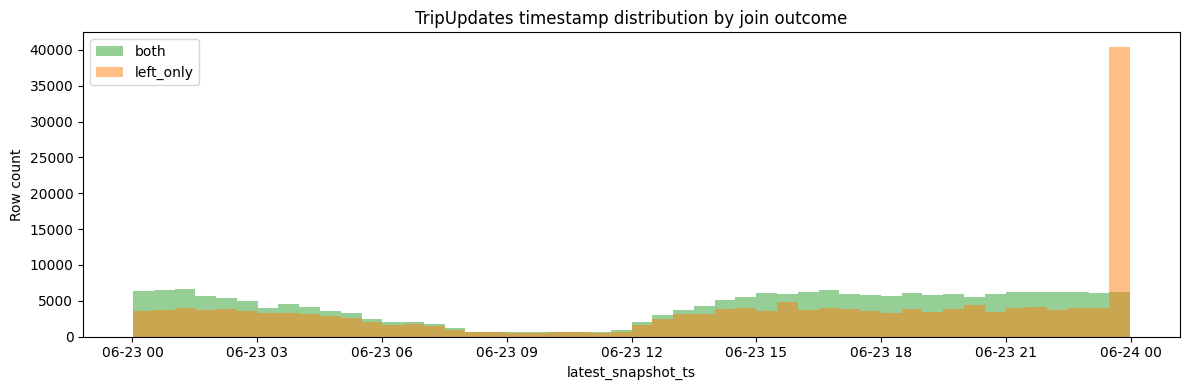

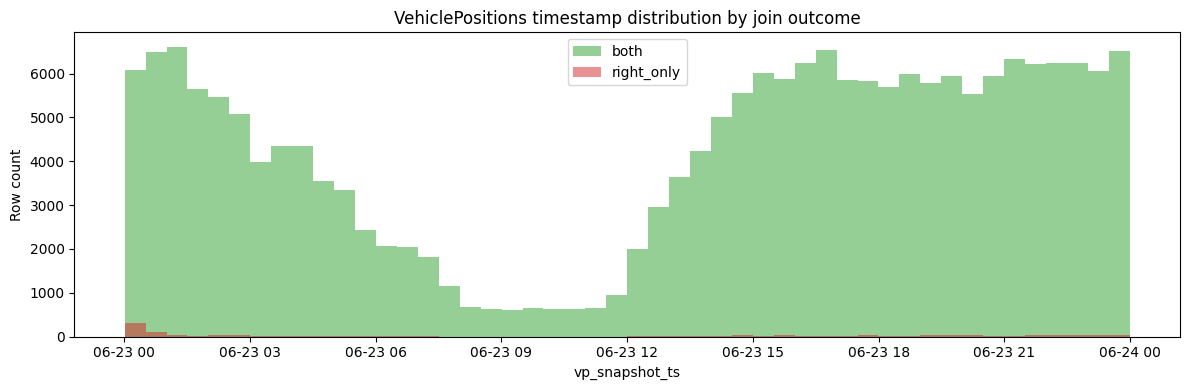

Hourly counts by TU timestamp hour:


/var/folders/nh/41dpg25d3yj1pq0sddg4xw680000gn/T/ipykernel_73692/3122939960.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["tu_hour", "_merge"])
/var/folders/nh/41dpg25d3yj1pq0sddg4xw680000gn/T/ipykernel_73692/3122939960.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["vp_hour", "_merge"])


_merge,left_only,right_only,both
tu_hour,,,
2026-06-23 00:00:00+00:00,7192,0,12922
2026-06-23 01:00:00+00:00,7707,0,12207
2026-06-23 02:00:00+00:00,6993,0,10177
2026-06-23 03:00:00+00:00,6839,0,8509
2026-06-23 04:00:00+00:00,6069,0,7932
2026-06-23 05:00:00+00:00,4599,0,5719
2026-06-23 06:00:00+00:00,3371,0,4118
2026-06-23 07:00:00+00:00,2449,0,2893
2026-06-23 08:00:00+00:00,1259,0,1310


Hourly counts by VP timestamp hour:


_merge,left_only,right_only,both
vp_hour,,,
2026-06-23 00:00:00+00:00,0,409,12573
2026-06-23 01:00:00+00:00,0,54,12252
2026-06-23 02:00:00+00:00,0,51,10246
2026-06-23 03:00:00+00:00,0,37,8556
2026-06-23 04:00:00+00:00,0,31,7959
2026-06-23 05:00:00+00:00,0,20,5775
2026-06-23 06:00:00+00:00,0,19,4121
2026-06-23 07:00:00+00:00,0,2,2960
2026-06-23 08:00:00+00:00,0,0,1316


In [31]:
import matplotlib.pyplot as plt

if "df_full_join" not in globals():
    raise ValueError("Run full outer join diagnostics first to create df_full_join.")

plot_df = df_full_join.copy()

# Ensure datetimes are parsed.
for c in ["latest_snapshot_ts", "vp_snapshot_ts"]:
    if c in plot_df.columns:
        plot_df[c] = pd.to_datetime(plot_df[c], utc=True, errors="coerce")

# Convert to hour-of-day buckets (UTC) for robust histogram binning.
plot_df["tu_hour"] = plot_df["latest_snapshot_ts"].dt.floor("H")
plot_df["vp_hour"] = plot_df["vp_snapshot_ts"].dt.floor("H")

# --- Histogram 1: TU timestamp distribution by join outcome ---
plt.figure(figsize=(12, 4))
for label, color in [("both", "tab:green"), ("left_only", "tab:orange")]:
    vals = plot_df.loc[plot_df["_merge"] == label, "latest_snapshot_ts"].dropna()
    if not vals.empty:
        plt.hist(vals, bins=48, alpha=0.5, label=label, color=color)

plt.title("TripUpdates timestamp distribution by join outcome")
plt.xlabel("latest_snapshot_ts")
plt.ylabel("Row count")
plt.legend()
plt.tight_layout()
plt.show()

# --- Histogram 2: VP timestamp distribution by join outcome ---
plt.figure(figsize=(12, 4))
for label, color in [("both", "tab:green"), ("right_only", "tab:red")]:
    vals = plot_df.loc[plot_df["_merge"] == label, "vp_snapshot_ts"].dropna()
    if not vals.empty:
        plt.hist(vals, bins=48, alpha=0.5, label=label, color=color)

plt.title("VehiclePositions timestamp distribution by join outcome")
plt.xlabel("vp_snapshot_ts")
plt.ylabel("Row count")
plt.legend()
plt.tight_layout()
plt.show()

# --- Hourly count table for quick edge diagnostics ---
tu_hourly = (
    plot_df.dropna(subset=["tu_hour"])
    .groupby(["tu_hour", "_merge"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

vp_hourly = (
    plot_df.dropna(subset=["vp_hour"])
    .groupby(["vp_hour", "_merge"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

print("Hourly counts by TU timestamp hour:")
display(tu_hourly.tail(24))

print("Hourly counts by VP timestamp hour:")
display(vp_hourly.tail(24))

## Step 10 - Infer arrivals via prediction crossing (experimental)

Instead of using "latest mention" of a stop, infer an arrival event when:

- previous snapshot predicts arrival in the future (`arrival_time_predicted - snapshot_ts > 0`)
- current snapshot predicts arrival at or before now (`arrival_time_predicted - snapshot_ts <= 0`)

This treats the crossing as an event-like signal and can reduce some false assumptions from latest-mention logic.

In [32]:
from pathlib import Path

# Raw TripUpdates parts produced by parse_tripupdates_day_to_parquet.py
# You can sample part files here if you want a faster trial.
tu_raw_dir = Path(f"../data/parquet/tripupdates_raw/{agency_id}_{service_date}")
tu_part_files = sorted(tu_raw_dir.glob("part-*.parquet"))

if not tu_part_files:
    raise ValueError(f"No TripUpdates raw part files found in: {tu_raw_dir}")

# Optional part sampling for speed during experimentation.
sample_tu_parts = False
sample_tu_part_n = 30
if sample_tu_parts:
    tu_part_files = tu_part_files[:sample_tu_part_n]

cols_needed = [
    "agency_id",
    "trip_id",
    "trip_start_date",
    "trip_start_time",
    "route_id",
    "direction_id",
    "stop_sequence",
    "stop_id",
    "snapshot_ts",
    "arrival_time_predicted",
]

tu_raw_list = [pd.read_parquet(p, columns=cols_needed) for p in tu_part_files]
df_tu_raw = pd.concat(tu_raw_list, ignore_index=True)

# Type normalization.
df_tu_raw["snapshot_ts"] = pd.to_datetime(df_tu_raw["snapshot_ts"], utc=True, errors="coerce")
df_tu_raw["arrival_time_predicted"] = pd.to_datetime(
    df_tu_raw["arrival_time_predicted"], utc=True, errors="coerce"
)
if "trip_start_date" in df_tu_raw.columns:
    df_tu_raw["trip_start_date"] = pd.to_datetime(df_tu_raw["trip_start_date"], errors="coerce").dt.date

print(f"Loaded TripUpdates raw rows: {len(df_tu_raw):,}")
print(f"Part files used: {len(tu_part_files):,}")
display(df_tu_raw.head())

Loaded TripUpdates raw rows: 35,999,522
Part files used: 144


,agency_id,trip_id,trip_start_date,trip_start_time,route_id,direction_id,stop_sequence,stop_id,snapshot_ts,arrival_time_predicted
0,muni,12053054_M41,2026-06-22,None,1,0,30,13896,2026-06-23 00:00:49+00:00,2026-06-23 00:01:04+00:00
1,muni,12053054_M41,2026-06-22,None,1,0,31,13852,2026-06-23 00:00:49+00:00,2026-06-23 00:02:18+00:00
2,muni,12053054_M41,2026-06-22,None,1,0,32,13845,2026-06-23 00:00:49+00:00,2026-06-23 00:03:13+00:00
3,muni,12053054_M41,2026-06-22,None,1,0,33,13822,2026-06-23 00:00:49+00:00,2026-06-23 00:04:20+00:00
4,muni,12053054_M41,2026-06-22,None,1,0,34,13824,2026-06-23 00:00:49+00:00,2026-06-23 00:05:13+00:00


In [33]:
# Compute crossing-based inferred arrivals.
tu_key_full = [
    "agency_id",
    "trip_id",
    "trip_start_date",
    "trip_start_time",
    "direction_id",
    "stop_sequence",
]

df_cross_base = df_tu_raw.dropna(subset=["trip_id", "stop_sequence", "snapshot_ts", "arrival_time_predicted"]).copy()
df_cross_base = df_cross_base.sort_values(tu_key_full + ["snapshot_ts"]).reset_index(drop=True)

# Horizon: positive means arrival predicted in the future.
df_cross_base["horizon_sec"] = (
    df_cross_base["arrival_time_predicted"] - df_cross_base["snapshot_ts"]
).dt.total_seconds()
df_cross_base["prev_horizon_sec"] = df_cross_base.groupby(tu_key_full, dropna=False)["horizon_sec"].shift(1)

cross_mask = (df_cross_base["prev_horizon_sec"] > 0) & (df_cross_base["horizon_sec"] <= 0)

df_tu_inferred = (
    df_cross_base.loc[cross_mask, [
        "agency_id",
        "trip_id",
        "trip_start_date",
        "trip_start_time",
        "route_id",
        "direction_id",
        "stop_sequence",
        "stop_id",
        "snapshot_ts",
        "arrival_time_predicted",
        "horizon_sec",
        "prev_horizon_sec",
    ]]
    .sort_values(tu_key_full + ["snapshot_ts"])
    .drop_duplicates(subset=tu_key_full, keep="first")
    .rename(columns={
        "snapshot_ts": "inferred_arrival_snapshot_ts",
        "arrival_time_predicted": "inferred_arrival_time_predicted",
    })
    .reset_index(drop=True)
)

print(f"Crossing events found: {cross_mask.sum():,}")
print(f"Unique inferred stop arrivals: {len(df_tu_inferred):,}")
display(df_tu_inferred.head())

Crossing events found: 54,920
Unique inferred stop arrivals: 53,846


,agency_id,trip_id,trip_start_date,trip_start_time,route_id,direction_id,stop_sequence,stop_id,inferred_arrival_snapshot_ts,inferred_arrival_time_predicted,horizon_sec,prev_horizon_sec
0,muni,12052958_M11,2026-06-23,None,1,0,6,13822,2026-06-23 11:35:22+00:00,2026-06-23 11:35:09+00:00,-13.0,67.0
1,muni,12052958_M11,2026-06-23,None,1,0,10,13831,2026-06-23 11:37:45+00:00,2026-06-23 11:37:30+00:00,-15.0,41.0
2,muni,12052958_M11,2026-06-23,None,1,0,13,13835,2026-06-23 11:40:10+00:00,2026-06-23 11:40:08+00:00,-2.0,70.0
3,muni,12052959_M11,2026-06-23,None,1,0,9,13828,2026-06-23 12:02:40+00:00,2026-06-23 12:02:39+00:00,-1.0,89.0
4,muni,12052959_M11,2026-06-23,None,1,0,11,13886,2026-06-23 12:04:39+00:00,2026-06-23 12:04:26+00:00,-13.0,18.0


In [34]:
# Compare inferred-arrival approach vs latest-mention approach.
join_key_basic = ["agency_id", "trip_id", "direction_id", "stop_sequence"]

# Key-level counts and overlap.
latest_keys = df_tu_latest[join_key_basic].drop_duplicates()
inferred_keys = df_tu_inferred[join_key_basic].drop_duplicates()

latest_minus_inferred = latest_keys.merge(inferred_keys, on=join_key_basic, how="left", indicator=True)
inferred_minus_latest = inferred_keys.merge(latest_keys, on=join_key_basic, how="left", indicator=True)

print("Key coverage comparison:")
print(f"Latest-mention keys: {len(latest_keys):,}")
print(f"Inferred-arrival keys: {len(inferred_keys):,}")
print(f"Latest-only keys: {(latest_minus_inferred['_merge'] == 'left_only').sum():,}")
print(f"Inferred-only keys: {(inferred_minus_latest['_merge'] == 'left_only').sum():,}")

# VP match-rate comparison on the same key.
vp_keys = df_vp_latest[join_key_basic + ["vehicle_id"]].copy()

latest_with_vp = latest_keys.merge(vp_keys, on=join_key_basic, how="left")
inferred_with_vp = inferred_keys.merge(vp_keys, on=join_key_basic, how="left")

latest_match_rate = latest_with_vp["vehicle_id"].notna().mean()
inferred_match_rate = inferred_with_vp["vehicle_id"].notna().mean()

print("\nVehicle match-rate comparison (key-based):")
print(f"Latest-mention TU keys with VP match: {latest_match_rate:.2%}")
print(f"Inferred-arrival TU keys with VP match: {inferred_match_rate:.2%}")

# Optional: where latest has no VP, what share are stop 1?
if "stop_sequence" in latest_with_vp.columns:
    latest_unmatched = latest_with_vp[latest_with_vp["vehicle_id"].isna()].copy()
    inferred_unmatched = inferred_with_vp[inferred_with_vp["vehicle_id"].isna()].copy()
    print("\nUnmatched stop_sequence == 1 share:")
    print(f"Latest-mention unmatched stop 1 share: {(latest_unmatched['stop_sequence'] == 1).mean():.2%}")
    print(f"Inferred-arrival unmatched stop 1 share: {(inferred_unmatched['stop_sequence'] == 1).mean():.2%}")

Key coverage comparison:
Latest-mention keys: 375,604
Inferred-arrival keys: 53,846
Latest-only keys: 321,758
Inferred-only keys: 0

Vehicle match-rate comparison (key-based):
Latest-mention TU keys with VP match: 53.75%
Inferred-arrival TU keys with VP match: 63.56%

Unmatched stop_sequence == 1 share:
Latest-mention unmatched stop 1 share: 1.31%
Inferred-arrival unmatched stop 1 share: 0.00%


In [ ]:
df_joined.to_parquet(output_joined_parquet, index=False)
print(f"Saved joined output: {output_joined_parquet}")

## Notes for production script

- This notebook proves the transformation logic.
- In production, parse VehiclePositions in chunks (as done for TripUpdates) to avoid memory pressure.
- Keep the same dedupe key and left-join key to preserve table semantics.
- If you need tighter matching later, add `vehicle_id` into TripUpdates processing and join with timestamp tolerance.

In [10]:
df_joined[df_joined['latest_snapshot_ts'].isna()]

,agency_id,trip_id,trip_start_date,trip_start_time,route_id,direction_id,stop_sequence,stop_id,latest_snapshot_ts,arrival_time_predicted,...,position_timestamp,vp_stop_id,current_status,vehicle_id,vehicle_label,latitude,longitude,bearing,speed,tu_vp_snapshot_delta_sec


In [ ]:
df_only_vp[df_only_vp['stop_sequence'] != 1]['current_status'].value_counts()

current_status
1.0    224
0.0     46
2.0     32
Name: count, dtype: int64

In [30]:
df_only_vp

,agency_id,trip_id,trip_start_date,trip_start_time,route_id,direction_id,stop_sequence,stop_id,latest_snapshot_ts,arrival_time_predicted,...,position_timestamp,vp_stop_id,current_status,vehicle_id,vehicle_label,latitude,longitude,bearing,speed,_merge
2085,muni,12053009_M11,NaN,NaN,NaN,0.0,1.0,NaN,NaT,NaT,...,2026-06-23 16:36:48+00:00,14277,2.0,5852,5852,37.779846,-122.492630,270.0,0.00,right_only
4448,muni,12053058_M41,NaN,NaN,NaN,0.0,8.0,NaN,NaT,NaT,...,2026-06-23 00:01:52+00:00,16316,1.0,5792,5792,37.793144,-122.407539,255.0,1.39,right_only
7241,muni,12053129_M41,NaN,NaN,NaN,0.0,1.0,NaN,NaT,NaT,...,2026-06-23 00:19:23+00:00,16313,2.0,5846,5846,37.788094,-122.447449,75.0,2.22,right_only
7242,muni,12053129_M41,NaN,NaN,NaN,0.0,11.0,NaN,NaT,NaT,...,2026-06-23 00:00:51+00:00,16301,1.0,5846,5846,37.792366,-122.414223,255.0,0.83,right_only
7290,muni,12053130_M41,NaN,NaN,NaN,0.0,1.0,NaN,NaT,NaT,...,2026-06-23 00:29:39+00:00,16313,2.0,5874,5874,37.788105,-122.447456,90.0,2.22,right_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376035,muni,12097616_M41,NaN,NaN,NaN,1.0,20.0,NaN,NaT,NaT,...,2026-06-23 00:00:51+00:00,14230,1.0,5856,5856,37.775795,-122.446091,75.0,0.00,right_only
376128,muni,12097618_M41,NaN,NaN,NaN,1.0,1.0,NaN,NaT,NaT,...,2026-06-23 00:48:05+00:00,17914,2.0,5802,5802,37.790272,-122.395386,210.0,0.00,right_only
377033,muni,12097949_M41,NaN,NaN,NaN,0.0,1.0,NaN,NaT,NaT,...,2026-06-23 00:41:38+00:00,14781,2.0,8638,8638,37.745716,-122.507591,165.0,0.00,right_only
377421,muni,12102715_M41,NaN,NaN,NaN,1.0,1.0,NaN,NaT,NaT,...,2026-06-23 00:22:59+00:00,16516,2.0,8634,8634,37.786793,-122.406471,165.0,0.00,right_only


In [19]:
df_only_tu

,agency_id,trip_id,trip_start_date,trip_start_time,route_id,direction_id,stop_sequence,stop_id,latest_snapshot_ts,arrival_time_predicted,...,position_timestamp,vp_stop_id,current_status,vehicle_id,vehicle_label,latitude,longitude,bearing,speed,_merge
2,muni,12052958_M11,2026-06-23,None,1,0.0,3.0,13896,2026-06-23 11:32:06+00:00,2026-06-23 11:33:38+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
4,muni,12052958_M11,2026-06-23,None,1,0.0,5.0,13845,2026-06-23 11:34:09+00:00,2026-06-23 11:34:41+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
5,muni,12052958_M11,2026-06-23,None,1,0.0,6.0,13822,2026-06-23 11:35:23+00:00,2026-06-23 11:35:09+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
8,muni,12052958_M11,2026-06-23,None,1,0.0,9.0,13828,2026-06-23 11:36:36+00:00,2026-06-23 11:36:52+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
9,muni,12052958_M11,2026-06-23,None,1,0.0,10.0,13831,2026-06-23 11:37:45+00:00,2026-06-23 11:37:30+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377485,muni,12102733_M41,2026-06-22,None,SF,1.0,3.0,13124,2026-06-23 00:05:08+00:00,2026-06-23 00:09:38+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
377486,muni,12102733_M41,2026-06-22,None,SF,1.0,4.0,13136,2026-06-23 00:05:08+00:00,2026-06-23 00:11:32+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
377487,muni,12102733_M41,2026-06-22,None,SF,1.0,5.0,14821,2026-06-23 00:05:08+00:00,2026-06-23 00:12:55+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
377488,muni,12102733_M41,2026-06-22,None,SF,1.0,6.0,16596,2026-06-23 00:05:08+00:00,2026-06-23 00:15:14+00:00,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [24]:
df_full_join['current_status'].value_counts()

current_status
1.0    95992
0.0    61539
2.0    45797
Name: count, dtype: int64

## Step 11 - Grain test: are VehiclePositions stop sequences contiguous per trip?

Hypothesis: if low match rate is driven by polling cadence (grain), VehiclePositions should observe a *gappy* subset of each trip's stop sequence rather than a perfect contiguous run.

Method (per `trip_id + direction_id`):
- collect the distinct `stop_sequence` values observed across the day
- look only within the observed `min..max` range (ignores not-catching the trip start/end)
- `expected_contiguous = max - min + 1`
- `n_missing = expected_contiguous - n_distinct`
- `fill_ratio = n_distinct / expected_contiguous`
- `max_gap` = largest run of consecutive missing sequence numbers

Reading the output:
- `has_gap` ratio answers the literal question, but will likely saturate near 100% (expected with 60s polling).
- `fill_ratio` / `n_missing` quantify *severity* (the real signal for grain).
- `max_gap` helps separate many-small-gaps (cadence) from one-huge-gap (short-turn / reroute / deviation).

In [35]:
if "df_vp_raw" not in globals():
    raise ValueError("Run the VehiclePositions parse cell first to create df_vp_raw.")

grain_key = ["trip_id", "direction_id"]

# Distinct (trip, direction, stop_sequence) observed by VehiclePositions.
vp_seq = df_vp_raw.dropna(subset=["trip_id", "stop_sequence"]).copy()
vp_seq["stop_sequence"] = vp_seq["stop_sequence"].astype(int)
vp_seq = vp_seq.drop_duplicates(grain_key + ["stop_sequence"])

# Per-trip contiguity stats (vectorized).
agg = vp_seq.groupby(grain_key, dropna=False)["stop_sequence"].agg(
    n_distinct="nunique",
    min_seq="min",
    max_seq="max",
)
agg["expected_contiguous"] = agg["max_seq"] - agg["min_seq"] + 1
agg["n_missing"] = agg["expected_contiguous"] - agg["n_distinct"]
agg["fill_ratio"] = agg["n_distinct"] / agg["expected_contiguous"]
agg["has_gap"] = agg["n_missing"] > 0

# Largest single gap (run of consecutive missing sequence numbers) per trip.
vp_sorted = vp_seq.sort_values(grain_key + ["stop_sequence"])
vp_sorted["gap"] = vp_sorted.groupby(grain_key, dropna=False)["stop_sequence"].diff() - 1
max_gap = vp_sorted.groupby(grain_key, dropna=False)["gap"].max().rename("max_gap")
agg = agg.join(max_gap)
agg["max_gap"] = agg["max_gap"].fillna(0).astype(int)

agg = agg.reset_index()

# Gaps are only meaningful when we observed at least 2 distinct stops.
analyzable = agg[agg["n_distinct"] >= 2].copy()

ratio_with_gaps = analyzable["has_gap"].mean()

print(f"Total trips (trip_id+direction): {len(agg):,}")
print(f"Analyzable trips (>=2 distinct stops observed): {len(analyzable):,}")
print(f"Ratio of analyzable trips with >=1 gap: {ratio_with_gaps:.2%}")

print("\nfill_ratio (observed_distinct / contiguous_range):")
display(analyzable["fill_ratio"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

print("n_missing (skipped stops within observed range):")
display(analyzable["n_missing"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

print("max_gap (largest consecutive skip):")
display(analyzable["max_gap"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

# Quick read on cadence vs deviation:
# many small gaps -> cadence; presence of a large single gap -> likely deviation/short-turn.
small_gap_share = (analyzable["max_gap"] <= 2).mean()
print(f"\nShare of gappy trips whose largest gap is <= 2 stops: {small_gap_share:.2%}")

display(analyzable.sort_values("n_missing", ascending=False).head(15))

Total trips (trip_id+direction): 9,479
Analyzable trips (>=2 distinct stops observed): 9,260
Ratio of analyzable trips with >=1 gap: 96.84%

fill_ratio (observed_distinct / contiguous_range):


count    9260.000000
mean        0.665218
std         0.165400
min         0.028986
5%          0.400000
25%         0.550000
50%         0.666667
75%         0.782609
95%         0.923077
max         1.000000
Name: fill_ratio, dtype: float64

n_missing (skipped stops within observed range):


count    9260.000000
mean       13.252160
std        10.835435
min         0.000000
5%          1.000000
25%         5.000000
50%        10.000000
75%        18.000000
95%        35.000000
max        76.000000
Name: n_missing, dtype: float64

max_gap (largest consecutive skip):


count    9260.000000
mean        3.252376
std         3.959608
min         0.000000
5%          1.000000
25%         2.000000
50%         2.000000
75%         4.000000
95%         7.000000
max        72.000000
Name: max_gap, dtype: float64


Share of gappy trips whose largest gap is <= 2 stops: 50.81%


,trip_id,direction_id,n_distinct,min_seq,max_seq,expected_contiguous,n_missing,fill_ratio,has_gap,max_gap
5463,12074056_M41,1.0,11,1,87,87,76,0.126437,True,72
2450,12063976_M41,1.0,2,1,69,69,67,0.028986,True,67
6579,12078147_M41,0.0,2,1,69,69,67,0.028986,True,67
3950,12068462_M41,1.0,15,1,81,81,66,0.185185,True,60
5711,12074522_M41,1.0,2,1,65,65,63,0.030769,True,63
2448,12063975_M41,1.0,9,1,69,69,60,0.130435,True,58
6581,12078148_M41,0.0,10,1,69,69,59,0.144928,True,50
4579,12071020_M11,1.0,21,1,80,80,59,0.262500,True,22
4586,12071027_M11,1.0,22,1,80,80,58,0.275000,True,14
5676,12074488_M11,1.0,2,1,60,60,58,0.033333,True,58
